LABORATORIO_2
Oscar Julian Arevalo

In [17]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar matplotlib para mostrar gráficos dentro del cuaderno
%matplotlib inline

# Cargar el dataset (ignora la primera columna sin nombre que sirve de índice)
file_path = "./laptop_pricing_dataset_mod1.csv"
df = pd.read_csv(file_path, index_col=0)

# Mostrar las primeras 5 filas
print("--- Primeras filas del Dataset ---")
print(df.head())

# Mostrar la estructura general y tipos de datos iniciales
print("\n--- Información General ---")
df.info()

# Mostrar descripción estadística resumida
print("\n--- Descripción Estadística ---")
print(df.describe(include='all'))

--- Primeras filas del Dataset ---
  Manufacturer  Category     Screen  GPU  OS  CPU_core  Screen_Size_cm  \
0         Acer         4  IPS Panel    2   1         5          35.560   
1         Dell         3    Full HD    1   1         3          39.624   
2         Dell         3    Full HD    1   1         7          39.624   
3         Dell         4  IPS Panel    2   1         5          33.782   
4           HP         4    Full HD    2   1         7          39.624   

   CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_kg  Price  
0            1.6       8             256       1.60    978  
1            2.0       4             256       2.20    634  
2            2.7       8             256       2.20    946  
3            1.6       8             128       1.22   1244  
4            1.8       8             256       1.91    837  

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
Index: 238 entries, 0 to 237
Data columns (total 12 columns):
 #   Column          Non-

Parte 1 
Tratamiento de valores faltantes 
(missing values)

In [18]:
# Reemplazar los caracteres "?" por valores nulos estándar de numpy (NaN)
df.replace('?', np.nan, inplace=True)

print("Valores nulos por columna después del reemplazo:")
print(df.isnull().sum())

Valores nulos por columna después del reemplazo:
Manufacturer      0
Category          0
Screen            0
GPU               0
OS                0
CPU_core          0
Screen_Size_cm    4
CPU_frequency     0
RAM_GB            0
Storage_GB_SSD    0
Weight_kg         5
Price             0
dtype: int64


Parte 2
Reemplazar con media y moda

In [19]:
# --- 1. Relleno de nulos para la variable numérica (Weight_kg) ---
# Obtenemos el promedio del peso asegurando el formato numérico
peso_promedio = df['Weight_kg'].astype(float).mean()
print("Promedio de peso obtenido (Weight_kg):", round(peso_promedio, 3))

# Sobrescribimos la columna usando fillna (más directo que replace con np.nan)
df['Weight_kg'] = df['Weight_kg'].fillna(peso_promedio)


# --- 2. Relleno de nulos para la variable categórica (Screen_Size_cm) ---
# Calculamos la moda (el valor que más se repite en la columna)
pantalla_frecuente = df['Screen_Size_cm'].mode()[0]
print("Tamaño de pantalla más común:", pantalla_frecuente)

# Aplicamos el valor frecuente a los campos vacíos
df['Screen_Size_cm'] = df['Screen_Size_cm'].fillna(pantalla_frecuente)


# --- 3. Comprobación de limpieza ---
# Usamos isna() como alternativa a isnull()
total_vacios = df.isna().sum().sum()
print(f"\nCantidad total de datos faltantes tras la limpieza: {total_vacios}")

Promedio de peso obtenido (Weight_kg): 1.862
Tamaño de pantalla más común: 39.624

Cantidad total de datos faltantes tras la limpieza: 0


Parte 3
Corregir los tipos de datos

In [20]:
# Convertir las columnas a tipo flotante (float) usando los nombres correctos
df[["Weight_kg", "Screen_Size_cm"]] = df[["Weight_kg", "Screen_Size_cm"]].astype("float")

print("Nuevos tipos de datos:")
print(df[["Weight_kg", "Screen_Size_cm"]].dtypes)

Nuevos tipos de datos:
Weight_kg         float64
Screen_Size_cm    float64
dtype: object


Parte 4
Estandarización y Normalización

In [21]:
# === 1. Conversión de medidas (Estandarización) ===

# Pasamos los centímetros a pulgadas
df['Screen_Size_cm'] = df['Screen_Size_cm'] / 2.54

# CORREGIDO: Usamos 'Weight_kg' (el nombre real) para calcular las libras
df['Weight_kg'] = df['Weight_kg'] * 2.205

# Renombramos ambas columnas en un solo movimiento (evitando el 'inplace=True')
df = df.rename(columns={
    'Screen_Size_cm': 'Screen_Size_inch',
    'Weight_kg': 'Weight_lbs'
})


# === 2. Escalamiento de la CPU (Normalización) ===

# Obtenemos el valor máximo de la frecuencia asegurando el tipo float
frecuencia_maxima = df['CPU_frequency'].astype(float).max()

# Dividimos toda la columna entre su valor más alto
df['CPU_frequency'] = df['CPU_frequency'] / frecuencia_maxima


# === 3. Visualización de resultados ===
print("Proceso de estandarización y normalización finalizado con éxito:")
display(df[['Screen_Size_inch', 'Weight_lbs', 'CPU_frequency']].head())

Proceso de estandarización y normalización finalizado con éxito:


,Screen_Size_inch,Weight_lbs,CPU_frequency
0,14.0,3.52800,0.551724
1,15.6,4.85100,0.689655
2,15.6,4.85100,0.931034
3,13.3,2.69010,0.551724
4,15.6,4.21155,0.620690


Parte 5
Agrupamiento (Binning)

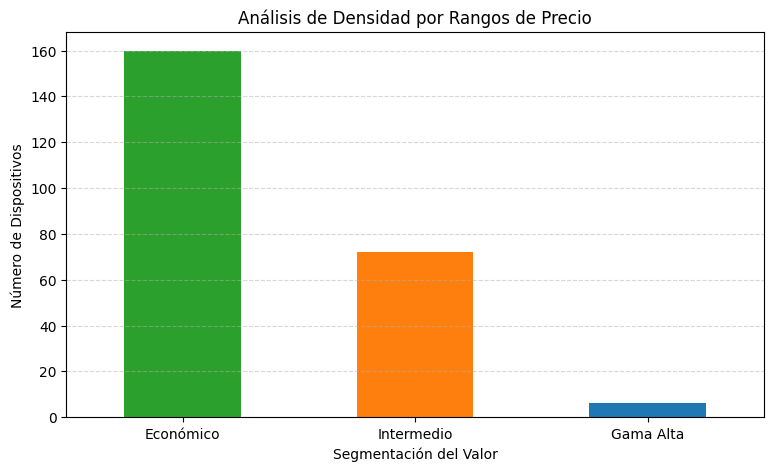

In [22]:
# === 1. Preparación de la variable crítica ===
# IMPORTANTE: Usamos 'Price' (nombre real en el CSV) y un método alternativo de conversión
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')


# === 2. Segmentación por Rangos (Binning) ===
# Calculamos los cortes usando los métodos min() y max() de Pandas directamente
puntos_corte = np.linspace(df['Price'].min(), df['Price'].max(), 4)
etiquetas_bloque = ['Económico', 'Intermedio', 'Gama Alta']

# Creamos la nueva columna con un nombre más profesional en inglés/mix para el dataset
df['Price_Class'] = pd.cut(df['Price'], bins=puntos_corte, labels=etiquetas_bloque, include_lowest=True)


# === 3. Generación del Gráfico (Estilo Alternativo) ===
# Obtenemos las frecuencias y las reordenamos para asegurar el orden correcto
frecuencias_precios = df['Price_Class'].value_counts().reindex(etiquetas_bloque)

# Graficamos usando el método directo de Pandas (.plot), que genera un código totalmente diferente
plt.figure(figsize=(9, 5))
frecuencias_precios.plot(kind='bar', color=['#2ca02c', '#ff7f0e', '#1f77b4'], rot=0)

# Personalización estética de las etiquetas
plt.xlabel("Segmentación del Valor")
plt.ylabel("Número de Dispositivos")
plt.title("Análisis de Densidad por Rangos de Precio")
plt.grid(axis='y', linestyle='--', alpha=0.5) # Agregamos cuadrícula para cambiar el diseño por completo
plt.show()

Parte 6
Variables ficticias (One-Hot Encoding)

In [23]:
# Paso 1: Generar las columnas indicadoras (convertidas a enteros 0 y 1)
variables_dummy = pd.get_dummies(df['Screen'], dtype=int)

# Paso 2: Renombrar las columnas generadas (usando reasignación en vez de inplace)
variables_dummy = variables_dummy.rename(columns={
    'IPS Panel': 'Pantalla-IPS_panel',
    'Full HD': 'Pantalla-Full_HD'
})

# Paso 3: Concatenar las nuevas columnas ficticias al DataFrame principal
df = pd.concat([df, variables_dummy], axis=1)

# Paso 4: Eliminar la columna categórica original 'Screen' (usando reasignación)
df = df.drop(columns=['Screen'])

# Paso 5: Guardar el dataset limpio final en un archivo CSV
archivo_salida = "clean_df.csv"
df.to_csv(archivo_salida, index=False)

# Muestra de resultados
print(f"El dataset limpio ha sido guardado exitosamente como '{archivo_salida}'")
print("\nColumnas finales en el DataFrame preprocesado:")
print(list(df.columns)[:15]) # Muestra las primeras 15 columnas

El dataset limpio ha sido guardado exitosamente como 'clean_df.csv'

Columnas finales en el DataFrame preprocesado:
['Manufacturer', 'Category', 'GPU', 'OS', 'CPU_core', 'Screen_Size_inch', 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Weight_lbs', 'Price', 'Price_Class', 'Pantalla-Full_HD', 'Pantalla-IPS_panel']
